/tmp/ipykernel_747/1587392675.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1587392675.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1587392675.py:24: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


[INFO] receivedAckPackets normalise.


/tmp/ipykernel_747/1587392675.py:49: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1587392675.py:49: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



--- Unconfirmed : energie par noeud (J) ---
      N     value
0    20  0.162114
1    50  0.160675
2   100  0.163026
3   200  0.162123
4   400  0.163750
5   600  0.159307
6   800  0.163035
7  1000  0.166167

--- Confirmed : energie par noeud (J) ---
      N     value
0    20  0.239384
1    50  0.262681
2   100  0.290100
3   200  0.313024
4   400  0.335836
5   600  0.342322
6   800  0.346936
7  1000  0.358028


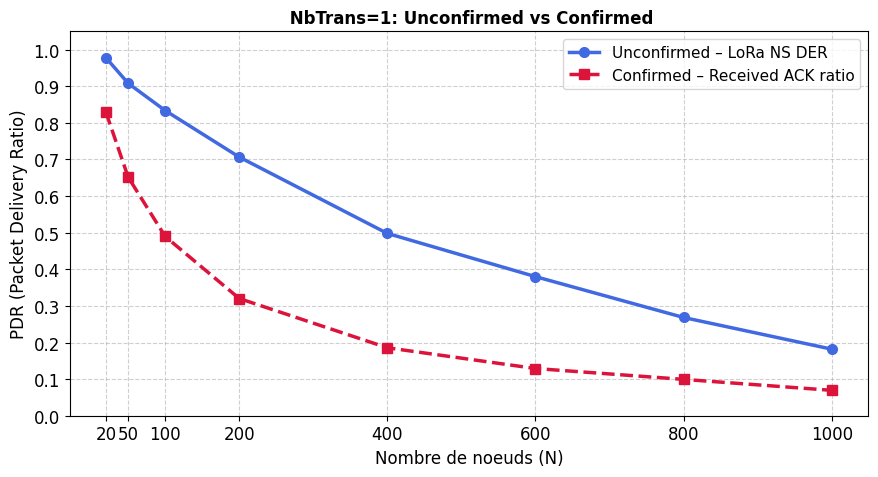

[OK] Figure sauvegardee : pdr_unconf_vs_conf.png


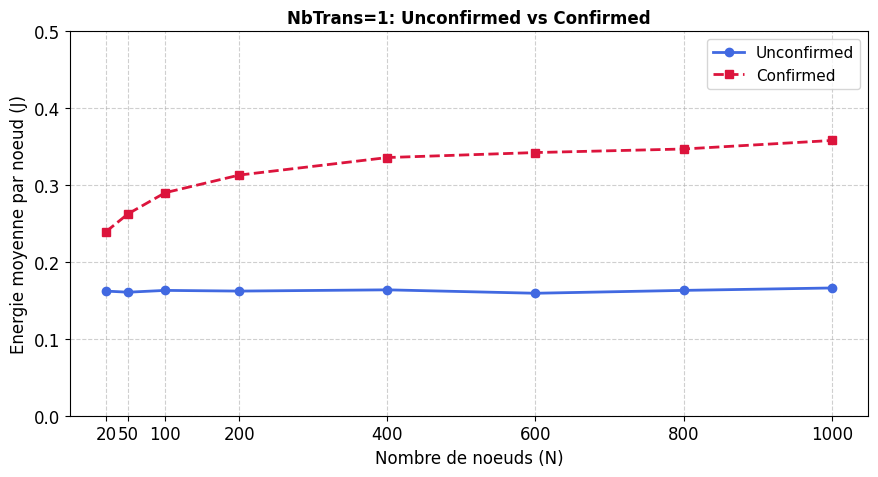

[OK] Figure sauvegardee : energy_unconf_vs_conf.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})
BASE = os.getcwd()

PATH_UNCONFIRMED = os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_CONFIRMED   = os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv")

custom_ticks = [ 20, 50, 100, 200, 400, 600, 800, 1000]

# ================================
# Fonction générique (PDR, etc.)
# ================================
def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")



def get_energy_per_node(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    # Extraire N par run
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))

    # Filtrer les lignes énergie des loRaNodes
    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    # Extraire l'index du nœud depuis le module : loRaNodes[i]
    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)

    # Pour chaque run, ne garder que les nœuds dont l'index < N du run
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]

    # Moyenne de l'énergie par nœud, par run → puis moyenne sur répétitions → par N
    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")
    return result


# ================================
# PDR
# ================================
der_unconf = get_results(PATH_UNCONFIRMED, "LoRa_NS_DER", module_filter="networkServer")
if der_unconf.empty:
    der_unconf = get_results(PATH_UNCONFIRMED, "LoRa_NS_DER")

ack_conf = get_results(PATH_CONFIRMED, "receivedAckPackets")
sent = get_results(PATH_CONFIRMED, "sentPackets")
if not sent.empty:
        merged = ack_conf.merge(sent, on="N", suffixes=("_ack", "_sent"))
        ack_conf = merged[["N"]].copy()
        ack_conf["value"] = merged["value_ack"] / merged["value_sent"]
        print("[INFO] receivedAckPackets normalise.")

# ================================
# Energie
# ================================
energy_unconf = get_energy_per_node(PATH_UNCONFIRMED)
energy_conf   = get_energy_per_node(PATH_CONFIRMED)

print("\n--- Unconfirmed : energie par noeud (J) ---")
print(energy_unconf)
print("\n--- Confirmed : energie par noeud (J) ---")
print(energy_conf)

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(9, 5))
if not der_unconf.empty:
    ax1.plot(der_unconf["N"], der_unconf["value"],
             marker="o", color="royalblue", lw=2.5, ms=7,
             label="Unconfirmed – LoRa NS DER")
if not ack_conf.empty:
    ax1.plot(ack_conf["N"], ack_conf["value"],
             marker="s", color="crimson", lw=2.5, ms=7, linestyle="--",
             label="Confirmed – Received ACK ratio")
ax1.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title(" NbTrans=1: Unconfirmed vs Confirmed",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_unconf_vs_conf.pdf", bbox_inches="tight")

plt.show()
print("[OK] Figure sauvegardee : pdr_unconf_vs_conf.png")

# ================================
# Figure 2 : Energie
# ================================
# Figure 2 : Energie
fig2, ax2 = plt.subplots(figsize=(9, 5))
if not energy_unconf.empty:
    eu = energy_unconf
    ax2.plot(eu["N"], eu["value"],
             marker="o", color="royalblue", linewidth=2,
             label="Unconfirmed")
if not energy_conf.empty:
    ec = energy_conf
    ax2.plot(ec["N"], ec["value"],
             marker="s", color="crimson", linewidth=2, linestyle="--",
             label="Confirmed")

ax2.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax2.set_ylabel("Energie moyenne par noeud (J)", fontsize=12)
ax2.set_title("NbTrans=1: Unconfirmed vs Confirmed",
              fontsize=12, fontweight="bold")
ax2.set_ylim(0, 0.5)
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_unconf_vs_conf.pdf", bbox_inches="tight")
plt.show()
print("[OK] Figure sauvegardee : energy_unconf_vs_conf.png")


/tmp/ipykernel_747/3090320232.py:35: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/3090320232.py:35: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


[INFO] receivedAckPackets normalise pour NbTrans = 1.


/tmp/ipykernel_747/3090320232.py:73: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



--- NbTrans = 1 : energie par noeud (J) ---
      N     value
0    20  0.239384
1    50  0.262681
2   100  0.290100
3   200  0.313024
4   400  0.335836
5   600  0.342322
6   800  0.346936
7  1000  0.358028


/tmp/ipykernel_747/3090320232.py:35: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/3090320232.py:35: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


...


--- NbTrans = 3 : energie par noeud (J) ---
      N     value
0    20  0.206025
1    50  0.345791
2   100  0.489881
3   200  0.594219
4   400  0.682034
5   600  0.700725
6   800  0.706737
7  1000  0.722257


/tmp/ipykernel_747/3090320232.py:35: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/3090320232.py:35: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


[INFO] receivedAckPackets normalise pour NbTrans = 8.


/tmp/ipykernel_747/3090320232.py:73: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



--- NbTrans = 8 : energie par noeud (J) ---
      N     value
0    20  0.221996
1    50  0.587882
2   100  1.227589
3   200  1.639206
4   400  1.745656
5   600  1.755947
6   800  1.810050
7  1000  1.831421


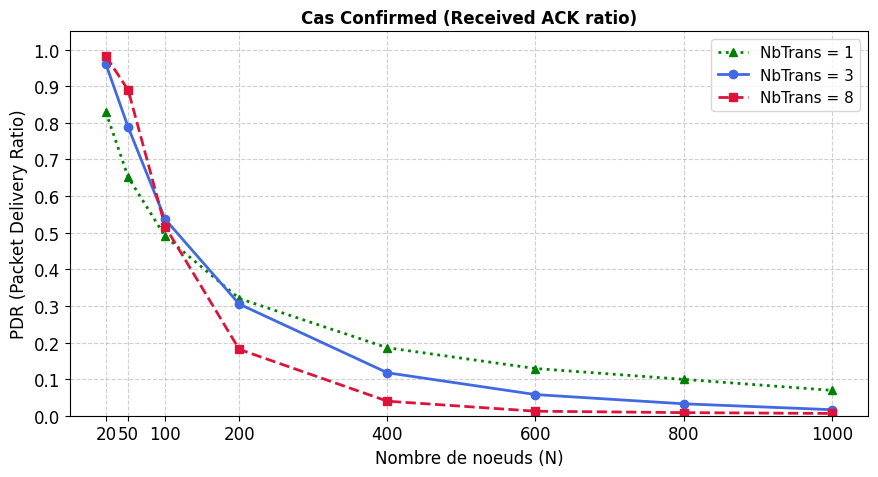

[OK] Figure sauvegardee : pdr_nbtrans_comparison.png


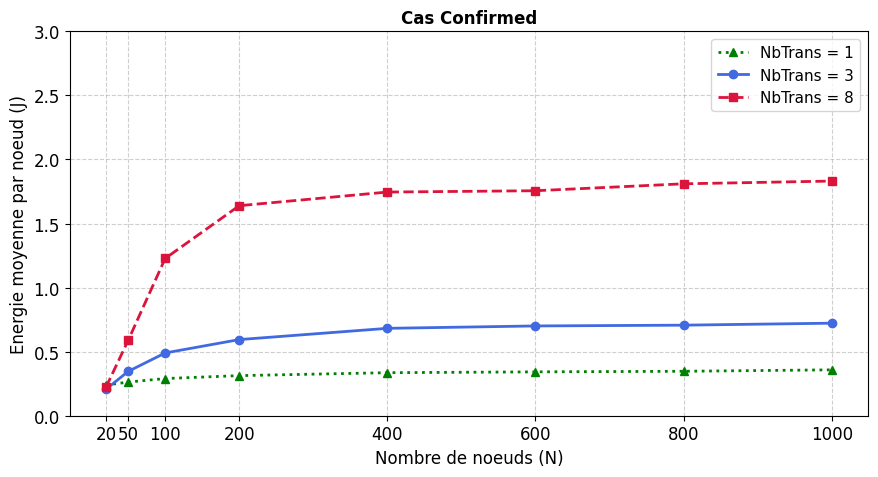

[OK] Figure sauvegardee : energy_nbtrans_comparison.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

# ================================
# Chemins vers les trois dossiers
# ================================
BASE = os.getcwd()

PATH_0RETX = os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv")
PATH_2RETX = os.path.join(BASE, "pureAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv")
PATH_7RETX = os.path.join(BASE, "pureAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv")

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

SERIES = [
    ("NbTrans = 1", PATH_0RETX, "green",     "^", ":"),
    ("NbTrans = 3", PATH_2RETX, "royalblue", "o", "-"),
    ("NbTrans = 8", PATH_7RETX, "crimson",   "s", "--"),
]

# ================================
# Fonction générique d'extraction
# ================================
def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_normalized_pdr(csv_path, label):
    """Calcule receivedAckPackets / sentPackets pour un scenario donne."""
    ack = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "sentPackets")
    if ack.empty or sent.empty:
        print(f"[WARN] Impossible de normaliser pour {label} — donnees manquantes.")
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    result = merged[["N"]].copy()
    result["value"] = merged["value_ack"] / merged["value_sent"]
    print(f"[INFO] receivedAckPackets normalise pour {label}.")
    return result


def get_energy_per_node(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))

    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]

    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    return mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")


# ================================
# Calcul des donnees (PDR + energie) pour chaque scenario
# ================================
pdr_data = {}
energy_data = {}

for label, path, color, marker, linestyle in SERIES:
    pdr_data[label] = get_normalized_pdr(path, label)
    energy_data[label] = get_energy_per_node(path)
    print(f"\n--- {label} : energie par noeud (J) ---")
    print(energy_data[label])

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(9, 5))
for label, path, color, marker, linestyle in SERIES:
    data = pdr_data[label]
    if not data.empty:
        ax1.plot(data["N"], data["value"],
                 marker=marker, color=color, linewidth=2, linestyle=linestyle,
                 label=label)

ax1.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title("Cas Confirmed (Received ACK ratio)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_nbtrans_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("[OK] Figure sauvegardee : pdr_nbtrans_comparison.png")

# ================================
# Figure 2 : Energie
# ================================
fig2, ax2 = plt.subplots(figsize=(9, 5))
for label, path, color, marker, linestyle in SERIES:
    data = energy_data[label]
    if not data.empty:
        ax2.plot(data["N"], data["value"],
                 marker=marker, color=color, linewidth=2, linestyle=linestyle,
                 label=label)

ax2.set_ylim(bottom=0, top=3)
ax2.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax2.set_ylabel("Energie moyenne par noeud (J)", fontsize=12)
ax2.set_title("Cas Confirmed", fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_nbtrans_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("[OK] Figure sauvegardee : energy_nbtrans_comparison.png")

/tmp/ipykernel_5902/3670118314.py:16: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_5902/3670118314.py:16: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_5902/3670118314.py:16: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_5902/3670118314.py:43: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_5902/3670118314.py:43: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_5902/3670118314.py:43: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_


--- NbTrans=1 : LoRa_NS_DER ---
      N     value
0    20  0.977818
1    50  0.908021
2   100  0.833616
3   200  0.706539
4   400  0.497973
5   600  0.358697
6   800  0.257232
7  1000  0.186959

--- NbTrans = 3 : LoRa_NS_DER ---
      N     value
0    20  0.995770
1    50  0.975432
2   100  0.923969
3   200  0.783842
4   400  0.483433
5   600  0.279600
6   800  0.163007
7  1000  0.100095

---  NbTrans=1 : energie par noeud (J) ---
      N     value
0    20  0.162114
1    50  0.160675
2   100  0.163026
3   200  0.162123
4   400  0.163750
5   600  0.162895
6   800  0.162789
7  1000  0.163625

---  NbTrans=3 : energie par noeud (J) ---
      N     value
0    20  0.486342
1    50  0.482026
2   100  0.489079
3   200  0.486368
4   400  0.491250
5   600  0.488684
6   800  0.488368
7  1000  0.498501

--- NbTrans = 8 : energie par noeud (J) ---
      N     value
0    20  1.296912
1    50  1.285403
2   100  1.304211
3   200  1.296982
4   400  1.310001
5   600  1.303158
6   800  1.304281
7  1000

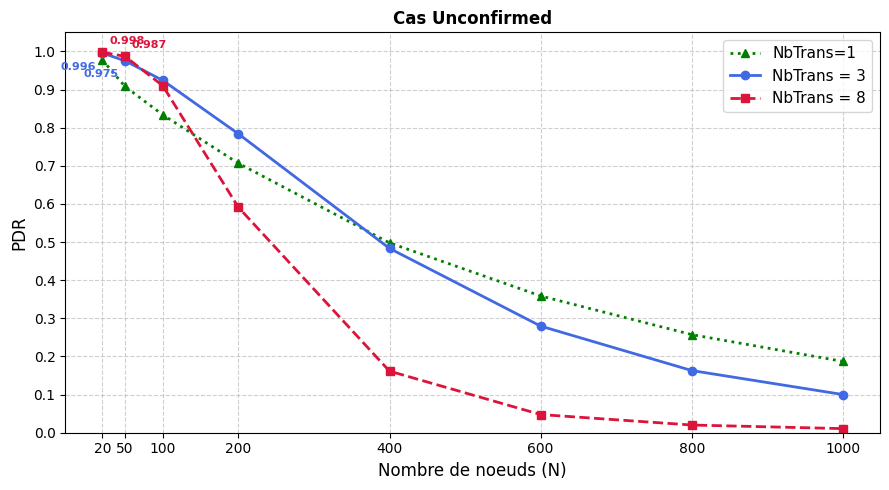

[OK] Figure sauvegardee : pdr_unconfirmed_0vs2retx.png


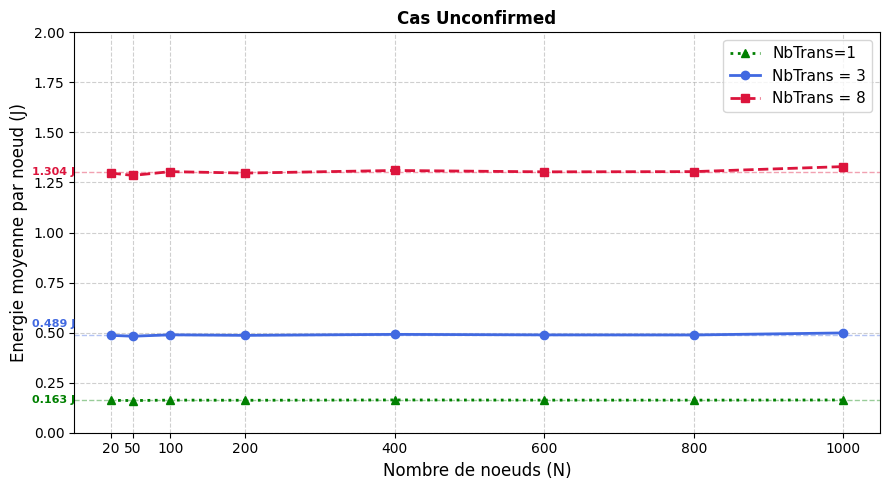

[OK] Figure sauvegardee : energy_unconfirmed_0vs2vs7retx.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

BASE = os.getcwd()

PATH_0RETX = os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_2RETX = os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_7RETX = os.path.join(BASE, "pureAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv")
custom_ticks = [ 20, 50, 100, 200, 400, 600, 800, 1000]
# ================================
# Fonction générique (PDR, etc.)
# ================================
def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


# ================================
# Fonction énergie par noeud
# ================================
def get_energy_per_node(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))

    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]

    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")
    return result


# ================================
# PDR — LoRa_NS_DER
# ================================
der_0retx = get_results(PATH_0RETX, "LoRa_NS_DER", module_filter="networkServer")
if der_0retx.empty:
    der_0retx = get_results(PATH_0RETX, "LoRa_NS_DER")

der_2retx = get_results(PATH_2RETX, "LoRa_NS_DER", module_filter="networkServer")
if der_2retx.empty:
    der_2retx = get_results(PATH_2RETX, "LoRa_NS_DER")
der_7retx = get_results(PATH_7RETX, "LoRa_NS_DER", module_filter="networkServer")
if der_7retx.empty:
    der_7retx = get_results(PATH_7RETX, "LoRa_NS_DER")

energy_7retx = get_energy_per_node(PATH_7RETX)
# ================================
# Energie
# ================================
energy_0retx = get_energy_per_node(PATH_0RETX)
energy_2retx = get_energy_per_node(PATH_2RETX)
energy_7retx = get_energy_per_node(PATH_7RETX)
print("\n--- NbTrans=1 : LoRa_NS_DER ---")
print(der_0retx)
print("\n--- NbTrans = 3 : LoRa_NS_DER ---")
print(der_2retx)
print("\n---  NbTrans=1 : energie par noeud (J) ---")
print(energy_0retx)
print("\n---  NbTrans=3 : energie par noeud (J) ---")
print(energy_2retx)
print("\n--- NbTrans = 8 : energie par noeud (J) ---")
print(energy_7retx)

# ================================
# Figure 1 : PDR (LoRa_NS_DER)
# ================================

fig1, ax1 = plt.subplots(figsize=(9, 5))

offsets = {
    "NbTrans = 3": (-30, -12),
    "NbTrans = 8": (5, 6),
}

for df_plot, marker, color, linestyle, label in [
    (der_0retx, "^", "green",      ":",  "NbTrans=1"),
    (der_2retx, "o", "royalblue",  "-",  "NbTrans = 3"),
    (der_7retx, "s", "crimson", "--", "NbTrans = 8"),
]:
    if df_plot.empty:
        continue
    ax1.plot(df_plot["N"], df_plot["value"],
             marker=marker, color=color, linewidth=2, linestyle=linestyle,
             label=label)

    if label not in offsets:
        continue

    for n_target in [20, 50]:
        row = df_plot[df_plot["N"] == n_target]
        if not row.empty:
            x = row["N"].values[0]
            y = row["value"].values[0]
            ax1.annotate(f"{y:.3f}",
                         xy=(x, y),
                         xytext=offsets[label],
                         textcoords="offset points",
                         fontsize=8,
                         color=color,
                         fontweight="bold")

ax1.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax1.set_ylabel("PDR", fontsize=12)
ax1.set_title("Cas Unconfirmed", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_unconfirmed_0vs2retx.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardee : pdr_unconfirmed_0vs2retx.png")

# ================================
# Figure 2 : Energie (Unconfirmed)
# ================================
# Dictionnaire d'offset X (en fraction d'axes) pour chaque courbe
label_x_offset = {
    "NbTrans=1":   -30,   # garde à gauche
    "NbTrans = 3": -30,   # on va le décaler via xycoords différent
    "NbTrans = 8": -30,
}

# Décalage Y supplémentaire (en points) pour éviter le chevauchement
label_y_offset = {
    "NbTrans=1":    0,
    "NbTrans = 3":  8,   # pousse vers le haut
    "NbTrans = 8":  0,
}

fig2, ax2 = plt.subplots(figsize=(9, 5))

for df_plot, marker, color, linestyle, label in [
    (energy_0retx, "^", "green",      ":",  "NbTrans=1"),
    (energy_2retx, "o", "royalblue",  "-",  "NbTrans = 3"),
    (energy_7retx, "s", "crimson", "--", "NbTrans = 8"),
]:
    if df_plot.empty:
        continue

    mean_val = df_plot["value"].mean()

    ax2.plot(df_plot["N"], df_plot["value"],
             marker=marker, color=color, linewidth=2, linestyle=linestyle,
             label=label)

    # Ligne horizontale à la moyenne
    ax2.axhline(y=mean_val, color=color, linewidth=1, linestyle="--", alpha=0.4)

    # Valeur moyenne annotée sur l'axe Y
    ax2.annotate(f"{mean_val:.3f} J",
             xy=(0, mean_val),
             xycoords=("axes fraction", "data"),
             xytext=(-30, label_y_offset[label]),
             textcoords="offset points",
             fontsize=8,
             color=color,
             fontweight="bold",
             va="center")

ax2.set_ylim(0,2)
ax2.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax2.set_ylabel("Energie moyenne par noeud (J)", fontsize=12)
ax2.set_title("Cas Unconfirmed", fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_unconfirmed_0vs2vs7retx.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardee : energy_unconfirmed_0vs2vs7retx.png")

/tmp/ipykernel_747/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs


--- 10B : LoRa_NS_DER ---
      N     value
0    20  0.995770
1    50  0.975432
2   100  0.923969
3   200  0.783842
4   400  0.483433
5   600  0.279600
6   800  0.163007
7  1000  0.100095

--- 59B : LoRa_NS_DER ---
      N     value
0    20  0.975405
1    50  0.884138
2   100  0.686364
3   200  0.364013
4   400  0.089907
5   600  0.027441
6   800  0.011329
7  1000  0.005999

--- 28B : LoRa_NS_DER ---
      N     value
0    20  0.988796
1    50  0.945482
2   100  0.847283
3   200  0.615165
4   400  0.265127
5   600  0.124449
6   800  0.049637
7  1000  0.027241

--- 10B : énergie par nœud (J) ---
      N     value
0    20  0.486342
1    50  0.482026
2   100  0.489079
3   200  0.486368
4   400  0.491250
5   600  0.488684
6   800  0.488368
7  1000  0.498501

--- 59B : énergie par nœud (J) ---
      N     value
0    20  1.277678
1    50  1.266340
2   100  1.284869
3   200  1.277747
4   400  1.290573
5   600  1.283832
6   800  1.283002
7  1000  1.289584

--- 28B : énergie par nœud (J) ---
 

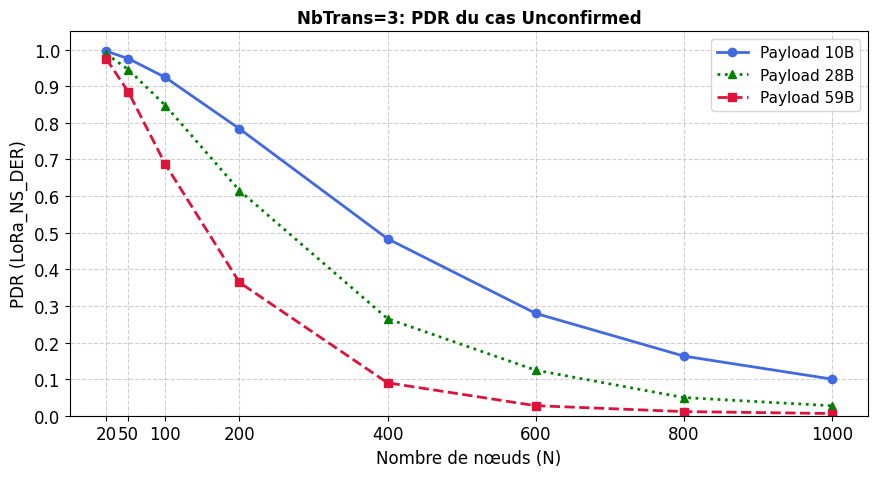

[OK] Figure sauvegardée : pdr_payload_comparison.png


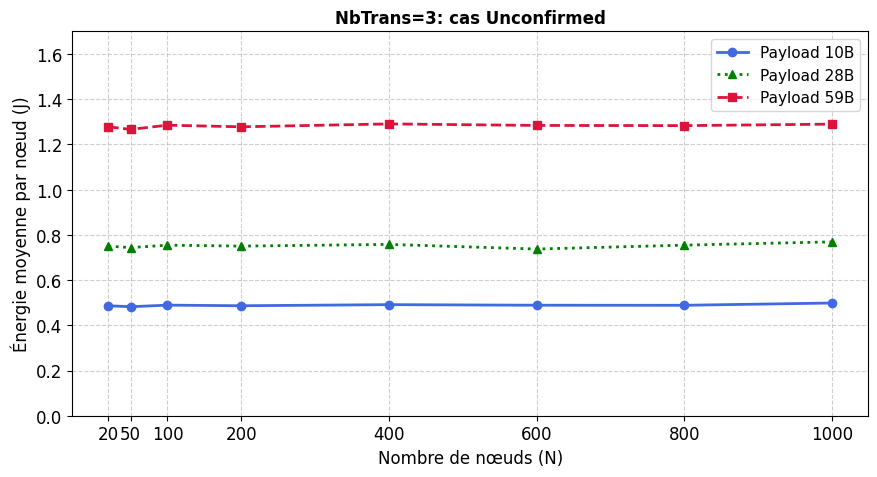

[OK] Figure sauvegardée : energy_payload_comparison.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

PATH_DEFAULT = os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_59B     = os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv")
PATH_28B     = os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv")

custom_ticks = [ 20, 50, 100, 200, 400, 600, 800, 1000]

def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_energy_per_node(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))
    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]
    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")
    return result

def load_der(path):
    der = get_results(path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(path, "LoRa_NS_DER")
    return der

der_default = load_der(PATH_DEFAULT)
der_59b     = load_der(PATH_59B)
der_28b     = load_der(PATH_28B)

energy_default = get_energy_per_node(PATH_DEFAULT)
energy_59b     = get_energy_per_node(PATH_59B)
energy_28b     = get_energy_per_node(PATH_28B)

# ================================
# Affichage console
# ================================
print("\n--- 10B : LoRa_NS_DER ---")
print(der_default)
print("\n--- 59B : LoRa_NS_DER ---")
print(der_59b)
print("\n--- 28B : LoRa_NS_DER ---")
print(der_28b)

print("\n--- 10B : énergie par nœud (J) ---")
print(energy_default)
print("\n--- 59B : énergie par nœud (J) ---")
print(energy_59b)
print("\n--- 28B : énergie par nœud (J) ---")
print(energy_28b)

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

if not der_default.empty:
    ax1.plot(der_default["N"], der_default["value"],
             marker="o", color="royalblue", linewidth=2,
             label="Payload 10B")
if not der_28b.empty:
    ax1.plot(der_28b["N"], der_28b["value"],
             marker="^", color="green", linewidth=2, linestyle=":",
             label="Payload 28B")
if not der_59b.empty:
    ax1.plot(der_59b["N"], der_59b["value"],
             marker="s", color="crimson", linewidth=2, linestyle="--",
             label="Payload 59B")

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (LoRa_NS_DER)", fontsize=12)
ax1.set_title("NbTrans=3: PDR du cas Unconfirmed",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_payload_comparison_aloha.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : pdr_payload_comparison.png")

# ================================
# Figure 2 : Énergie — courbes par taille de payload
# ================================
# ================================
# Figure 2 : Énergie — courbes par taille de payload
# ================================
fig2, ax2 = plt.subplots(figsize=(9, 5))

for df_plot, marker, color, linestyle, label in [
    (energy_default, "o", "royalblue",  "-",  "Payload 10B"),
    (energy_28b,     "^", "green",      ":",  "Payload 28B"),
    (energy_59b,     "s", "crimson", "--", "Payload 59B"),
]:
    if df_plot.empty:
        continue

    mean_val = df_plot["value"].mean()

    ax2.plot(df_plot["N"], df_plot["value"],
             marker=marker, color=color, linewidth=2, linestyle=linestyle,
             label=label)



ax2.set_ylim(0, 1.7)
ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_title("NbTrans=3: cas Unconfirmed", fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11, loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.6)
plt.subplots_adjust(left=0.18) 
plt.tight_layout()
plt.savefig("energy_payload_comparison_aloha.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : energy_payload_comparison.png")


/tmp/ipykernel_747/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_747/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs


--- 10B : LoRa_NS_DER ---
      N     value
0    20  0.995770
1    50  0.975432
2   100  0.923969
3   200  0.783842
4   400  0.483433
5   600  0.279600
6   800  0.163007
7  1000  0.100095

--- 59B : LoRa_NS_DER ---
      N     value
0    20  0.975405
1    50  0.884138
2   100  0.686364
3   200  0.364013
4   400  0.089907
5   600  0.027441
6   800  0.011329
7  1000  0.005999

--- 28B : LoRa_NS_DER ---
      N     value
0    20  0.988796
1    50  0.945482
2   100  0.847283
3   200  0.615165
4   400  0.265127
5   600  0.124449
6   800  0.049637
7  1000  0.027241

--- 10B : énergie par nœud (J) ---
      N     value
0    20  0.486342
1    50  0.482026
2   100  0.489079
3   200  0.486368
4   400  0.491250
5   600  0.488684
6   800  0.488368
7  1000  0.498501

--- 59B : énergie par nœud (J) ---
      N     value
0    20  1.277678
1    50  1.266340
2   100  1.284869
3   200  1.277747
4   400  1.290573
5   600  1.283832
6   800  1.283002
7  1000  1.289584

--- 28B : énergie par nœud (J) ---
 

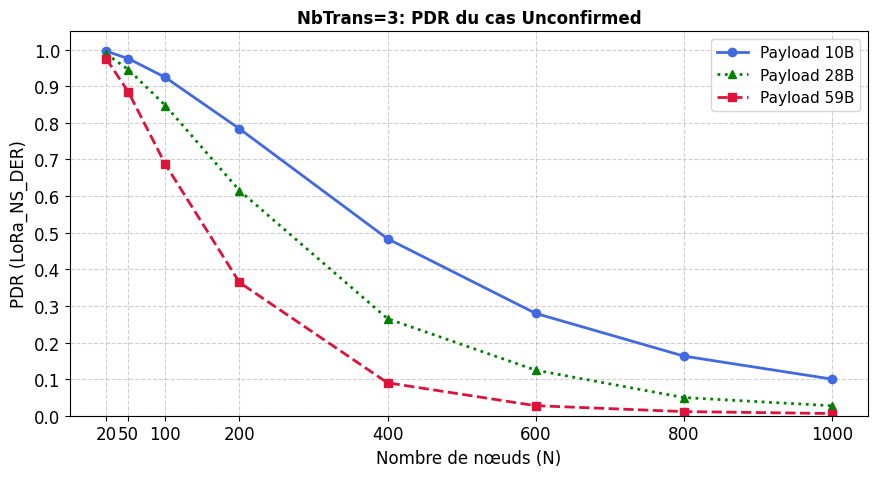

[OK] Figure sauvegardée : pdr_payload_comparison.png


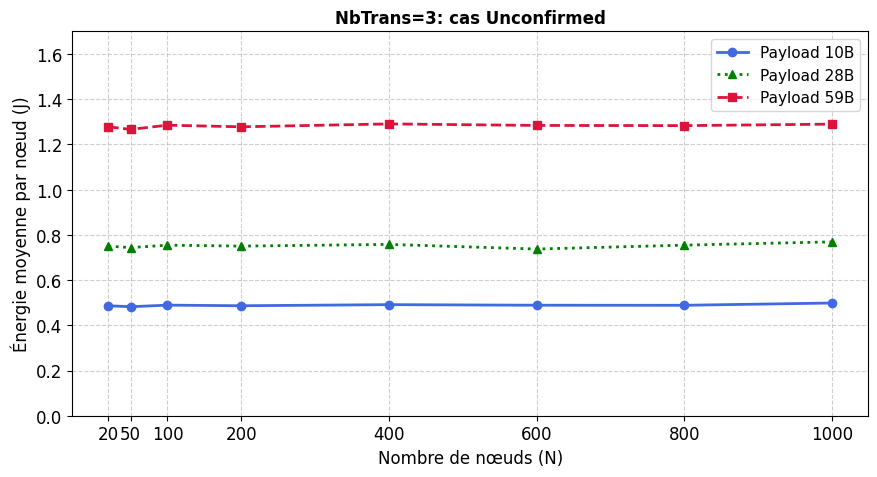

[OK] Figure sauvegardée : energy_payload_comparison.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

PATH_DEFAULT = os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_59B     = os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv")
PATH_28B     = os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv")

custom_ticks = [ 20, 50, 100, 200, 400, 600, 800, 1000]

def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_energy_per_node(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))
    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]
    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")
    return result

def load_der(path):
    der = get_results(path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(path, "LoRa_NS_DER")
    return der

der_default = load_der(PATH_DEFAULT)
der_59b     = load_der(PATH_59B)
der_28b     = load_der(PATH_28B)

energy_default = get_energy_per_node(PATH_DEFAULT)
energy_59b     = get_energy_per_node(PATH_59B)
energy_28b     = get_energy_per_node(PATH_28B)

# ================================
# Affichage console
# ================================
print("\n--- 10B : LoRa_NS_DER ---")
print(der_default)
print("\n--- 59B : LoRa_NS_DER ---")
print(der_59b)
print("\n--- 28B : LoRa_NS_DER ---")
print(der_28b)

print("\n--- 10B : énergie par nœud (J) ---")
print(energy_default)
print("\n--- 59B : énergie par nœud (J) ---")
print(energy_59b)
print("\n--- 28B : énergie par nœud (J) ---")
print(energy_28b)

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

if not der_default.empty:
    ax1.plot(der_default["N"], der_default["value"],
             marker="o", color="royalblue", linewidth=2,
             label="Payload 10B")
if not der_28b.empty:
    ax1.plot(der_28b["N"], der_28b["value"],
             marker="^", color="green", linewidth=2, linestyle=":",
             label="Payload 28B")
if not der_59b.empty:
    ax1.plot(der_59b["N"], der_59b["value"],
             marker="s", color="crimson", linewidth=2, linestyle="--",
             label="Payload 59B")

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (LoRa_NS_DER)", fontsize=12)
ax1.set_title("NbTrans=3: PDR du cas Unconfirmed",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_payload_comparison_aloha.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : pdr_payload_comparison.png")

# ================================
# Figure 2 : Énergie — courbes par taille de payload
# ================================
# ================================
# Figure 2 : Énergie — courbes par taille de payload
# ================================
fig2, ax2 = plt.subplots(figsize=(9, 5))

for df_plot, marker, color, linestyle, label in [
    (energy_default, "o", "royalblue",  "-",  "Payload 10B"),
    (energy_28b,     "^", "green",      ":",  "Payload 28B"),
    (energy_59b,     "s", "crimson", "--", "Payload 59B"),
]:
    if df_plot.empty:
        continue

    mean_val = df_plot["value"].mean()

    ax2.plot(df_plot["N"], df_plot["value"],
             marker=marker, color=color, linewidth=2, linestyle=linestyle,
             label=label)



ax2.set_ylim(0, 1.7)
ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_title("NbTrans=3: cas Unconfirmed", fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11, loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.6)
plt.subplots_adjust(left=0.18) 
plt.tight_layout()
plt.savefig("energy_payload_comparison_aloha.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : energy_payload_comparison.png")


/tmp/ipykernel_1365/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1365/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1365/1841945127.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1365/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1365/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_1365/1841945127.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_


--- 10B : LoRa_NS_DER ---
      N     value
0    20  0.995770
1    50  0.975432
2   100  0.923969
3   200  0.783842
4   400  0.483433
5   600  0.279600
6   800  0.163007
7  1000  0.100095

--- 59B : LoRa_NS_DER ---
      N     value
0    20  0.975405
1    50  0.884138
2   100  0.686364
3   200  0.364013
4   400  0.089907
5   600  0.027441
6   800  0.011329
7  1000  0.005999

--- 28B : LoRa_NS_DER ---
      N     value
0    20  0.988796
1    50  0.945482
2   100  0.847283
3   200  0.615165
4   400  0.265127
5   600  0.124449
6   800  0.049637
7  1000  0.027241

--- 10B : énergie par nœud (J) ---
      N     value
0    20  0.486342
1    50  0.482026
2   100  0.489079
3   200  0.486368
4   400  0.491250
5   600  0.488684
6   800  0.488368
7  1000  0.498501

--- 59B : énergie par nœud (J) ---
      N     value
0    20  1.277678
1    50  1.266340
2   100  1.284869
3   200  1.277747
4   400  1.290573
5   600  1.283832
6   800  1.283002
7  1000  1.289584

--- 28B : énergie par nœud (J) ---
 

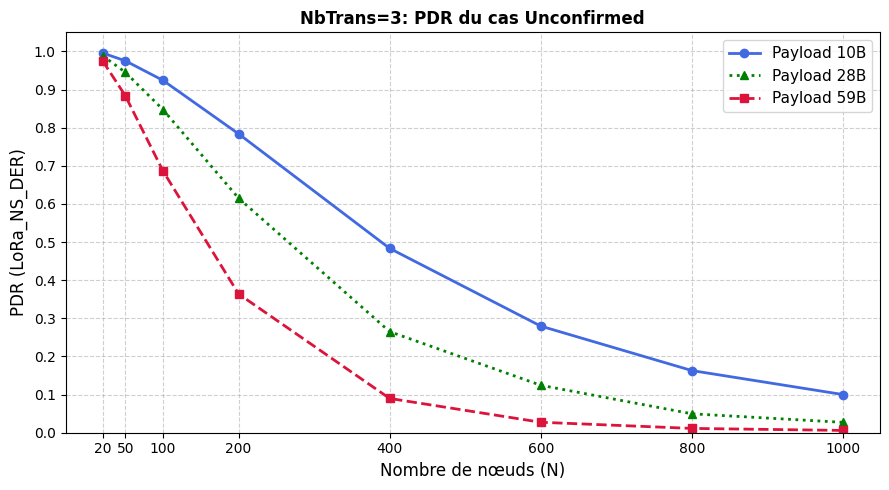

[OK] Figure sauvegardée : pdr_payload_comparison.png


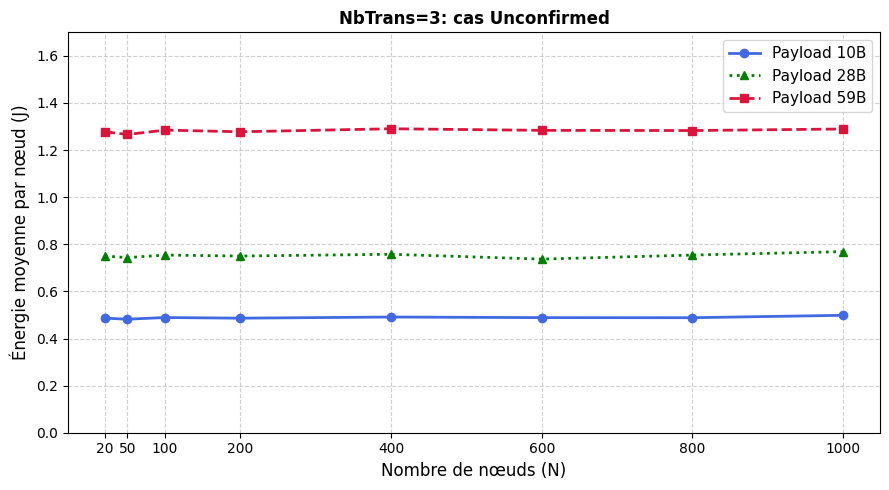

[OK] Figure sauvegardée : energy_payload_comparison.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

PATH_DEFAULT = os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_59B     = os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv")
PATH_28B     = os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv")

custom_ticks = [ 20, 50, 100, 200, 400, 600, 800, 1000]

def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_energy_per_node(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))
    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]
    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")
    return result

def load_der(path):
    der = get_results(path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(path, "LoRa_NS_DER")
    return der

der_default = load_der(PATH_DEFAULT)
der_59b     = load_der(PATH_59B)
der_28b     = load_der(PATH_28B)

energy_default = get_energy_per_node(PATH_DEFAULT)
energy_59b     = get_energy_per_node(PATH_59B)
energy_28b     = get_energy_per_node(PATH_28B)

# ================================
# Affichage console
# ================================
print("\n--- 10B : LoRa_NS_DER ---")
print(der_default)
print("\n--- 59B : LoRa_NS_DER ---")
print(der_59b)
print("\n--- 28B : LoRa_NS_DER ---")
print(der_28b)

print("\n--- 10B : énergie par nœud (J) ---")
print(energy_default)
print("\n--- 59B : énergie par nœud (J) ---")
print(energy_59b)
print("\n--- 28B : énergie par nœud (J) ---")
print(energy_28b)

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

if not der_default.empty:
    ax1.plot(der_default["N"], der_default["value"],
             marker="o", color="royalblue", linewidth=2,
             label="Payload 10B")
if not der_28b.empty:
    ax1.plot(der_28b["N"], der_28b["value"],
             marker="^", color="green", linewidth=2, linestyle=":",
             label="Payload 28B")
if not der_59b.empty:
    ax1.plot(der_59b["N"], der_59b["value"],
             marker="s", color="crimson", linewidth=2, linestyle="--",
             label="Payload 59B")

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (LoRa_NS_DER)", fontsize=12)
ax1.set_title("NbTrans=3: PDR du cas Unconfirmed",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_payload_comparison_aloha.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : pdr_payload_comparison.png")

# ================================
# Figure 2 : Énergie — courbes par taille de payload
# ================================
# ================================
# Figure 2 : Énergie — courbes par taille de payload
# ================================
fig2, ax2 = plt.subplots(figsize=(9, 5))

for df_plot, marker, color, linestyle, label in [
    (energy_default, "o", "royalblue",  "-",  "Payload 10B"),
    (energy_28b,     "^", "green",      ":",  "Payload 28B"),
    (energy_59b,     "s", "crimson", "--", "Payload 59B"),
]:
    if df_plot.empty:
        continue

    mean_val = df_plot["value"].mean()

    ax2.plot(df_plot["N"], df_plot["value"],
             marker=marker, color=color, linewidth=2, linestyle=linestyle,
             label=label)



ax2.set_ylim(0, 1.7)
ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_title("NbTrans=3: cas Unconfirmed", fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11, loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.6)
plt.subplots_adjust(left=0.18) 
plt.tight_layout()
plt.savefig("energy_payload_comparison_aloha.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : energy_payload_comparison.png")
